# Computational Statistical Mechanics

Monte Carlo Rejection Algorithm for Activity Selection

simulations = 10000

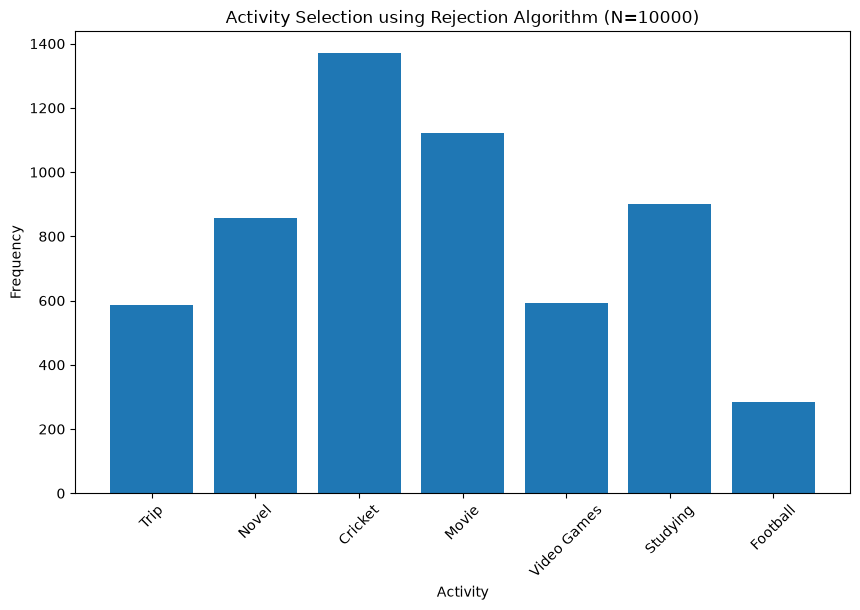

Rejection Algorithm Results

Activity  | Expected Count | Actual Count
Trip         |         1000 |        587
Novel        |         1500 |        857
Cricket      |         2500 |       1370
Movie        |         2000 |       1122
Video Games  |         1000 |        593
Studying     |         1500 |        901
Football     |          500 |        284


In [5]:
import random
import matplotlib.pyplot as plt
import numpy as np

activities = ['Trip', 'Novel', 'Cricket', 'Movie', 'Video Games', 'Studying', 'Football']
probabilities = [0.1, 0.15, 0.25, 0.2, 0.1, 0.15, 0.05]


def rejection_sampling(N):
    results=[]
    max_prob = max(probabilities)

    for i in range(N):
        u = random.uniform(0,max_prob)
        z = random.randint(0,len(activities)-1)

        #acceptance
        if u <= probabilities[z]:
            results.append(activities[z])
    
    return results

N=10000
Results = rejection_sampling(10000)

plt.figure(figsize=(10,6))
act_count = [Results.count(act) for act in activities]

plt.bar(activities,act_count)
plt.title('Activity Selection using Rejection Algorithm (N={0})'.format(N))
plt.xlabel('Activity')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

print("Rejection Algorithm Results")
print("\nActivity  | Expected Count | Actual Count")
for i, act in enumerate(activities):
    expected = probabilities[i] * N
    actual = Results.count(act)
    print("{0:12} | {1:12.0f} | {2:10}".format(act, expected, actual))


# Rejection-free Monte Carlo (tower sampling)

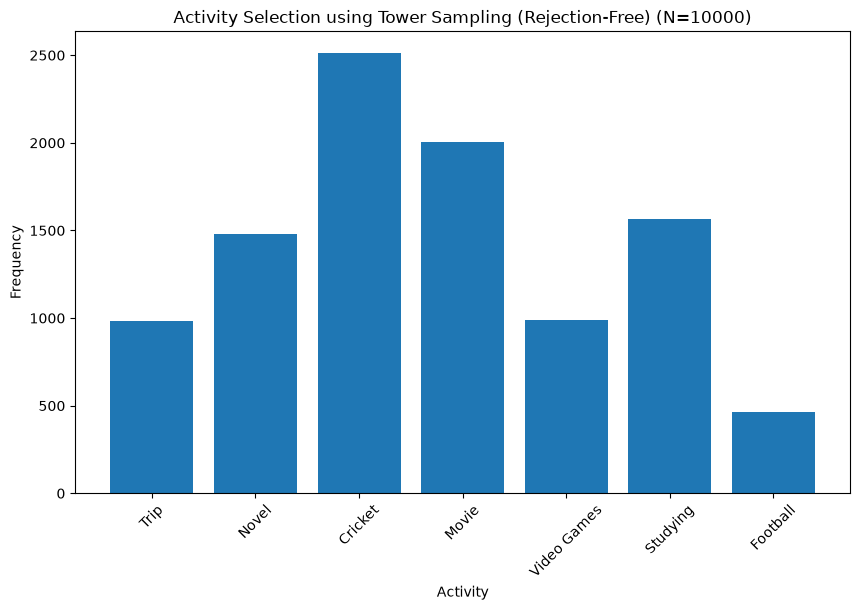

Tower Sampling (Rejection-Free) Results

Activity    | Expected Count | Actual Count
Trip         |         1000 |        982 
Novel        |         1500 |       1480 
Cricket      |         2500 |       2511 
Movie        |         2000 |       2005 
Video Games  |         1000 |        990 
Studying     |         1500 |       1566 
Football     |          500 |        466 


In [6]:
import random
import matplotlib.pyplot as plt
import numpy as np

activities = ['Trip', 'Novel', 'Cricket', 'Movie', 'Video Games', 'Studying', 'Football']
probabilities = [0.1, 0.15, 0.25, 0.2, 0.1, 0.15, 0.05]


def tower_sampling(N):
    results = []

    Pi = [0] * (len(probabilities) + 1)
    for l in range(1, len(probabilities) + 1):
        Pi[l] = Pi[l-1] + probabilities[l-1]
    
    for i in range(N):
        gamma = random.uniform(0, Pi[-1])
        
        for k in range(1, len(Pi)):
            if gamma <= Pi[k]:
                results.append(activities[k-1])
                break
    
    return results

N=10000
Results_tower = tower_sampling(N)

plt.figure(figsize=(10, 6))
activity_count_tower = [Results_tower.count(act) for act in activities]
plt.bar(activities, activity_count_tower)
plt.title('Activity Selection using Tower Sampling (Rejection-Free) (N={0})'.format(N))
plt.xlabel('Activity')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

print("Tower Sampling (Rejection-Free) Results")
print("\nActivity    | Expected Count | Actual Count")
for i, act in enumerate(activities):
    expected = probabilities[i] * N
    actual = Results_tower.count(act)
    print("{0:12} | {1:12.0f} | {2:10} ".format(act, expected, actual))


# 2) Disk Motion with Wall Collision Detection

Disk Motion with Wall Collision Detection

In [1]:
class Disk:
    def __init__(self, x=0, y=0, vx=0.2, vy=0.4, radius=0.01):
        self.x = x          
        self.y = y          
        self.vx = vx        
        self.vy = vy       
        self.radius = radius  
    